# Lab 30 — Wireline and Optical Links: Copper Loops, DSL and Vectoring, Fibre Dispersion, Coherent DSP and Optical Budgets

**Companion to Chapter 24** (*Wireline and Optical*). Lab 13 covers line codes and SerDes; Lab 28 has a DMT bit-loading
section; this lab follows a bit from the telephone exchange to the transoceanic cable.
**Time needed:** about 2 hours. **Difficulty:** core.

Wires and fibres are the channels that wireless engineers envy: static, private and enormous. A twisted pair laid for 3 kHz
voice carries tens of megabits per second because DMT loads every tone to its SNR and vectoring cancels the crosstalk from
its neighbours; a single-mode fibre carries tens of terabits per second because a coherent receiver undoes thousands of
picoseconds of dispersion in DSP and only the amplifiers' noise and the glass's nonlinearity remain. This lab computes all of
it with `commlib/wireline.py`, the module behind Chapter 24's figures.

### What you will learn
1. Compute the loss, impedance and delay of a twisted-pair loop from the RLGC model, and see loading coils and bridged taps.
2. Load bits on DMT tones and draw rate-versus-reach curves for ADSL2+ and VDSL2.
3. Build a vectored binder with a random FEXT matrix and compare zero-forcing precoding with no cancellation.
4. Propagate PAM-4 intensity modulation and coherent QPSK through dispersive fibre, and see why one fails and the other does not.
5. Run the coherent receiver chain: CD compensation, CMA polarisation demultiplexing, frequency and phase recovery.
6. Plan an amplified link: OSNR, the optimum launch power of the GN model, margin, and a PON power budget.

### Prerequisites
Lab 28 §6 (DMT). Transmission lines (Chapter 24, Section 24.2). Lab 6 (CMA). Chapter 24.

### Roadmap
| § | Topic | Interactive |
|---|-------|:-----------:|
| 1 | The copper loop: RLGC, loss, loading coils, bridged taps | yes |
| 2 | DSL: bit loading and rate versus reach | yes |
| 3 | Crosstalk and vectoring | yes |
| 4 | Fibre: loss, dispersion, IM/DD versus coherent | yes |
| 5 | The coherent receiver DSP chain | yes |
| 6 | Optical budgets: OSNR, nonlinearity, PON | yes |

In [1]:
import os, sys
os.environ.setdefault("OPENBLAS_NUM_THREADS", "2")   # small matrices: avoid BLAS thread thrashing
sys.path[:0] = [p for p in (os.path.abspath(".."), os.path.abspath("."))
                if os.path.isdir(os.path.join(p, "commlib"))]
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq
import commlib as cl
from commlib import wireline as wl
from commlib import labkit as lk

rng = lk.setup(seed=30, lab="30")
NOISE, GAP = -140.0, 12.0          # background noise (dBm/Hz) and SNR gap (dB), as in Chapter 24
VDSL_DS = [(138e3, 3.75e6), (5.2e6, 8.5e6), (12e6, 17.664e6)]       # 998ADE17 downstream bands


def adsl_rate(L, n_fext=10, psd=-40.0, noise=NOISE, gap=GAP, return_all=False):
    """ADSL2+ downstream line rate on L metres of 26 AWG (tones 33-511), FEXT from n_fext lines."""
    f = np.arange(33, 512) * 4312.5
    h2 = np.abs(wl.loop_gain(f, L, 26)) ** 2
    fext = psd + lk.db(wl.fext_coupling(f, L, np.sqrt(h2), n_fext) + 1e-30) if n_fext else np.full_like(f, -300.0)
    r, b, snr = wl.dmt_rate(f, psd, h2, wl.db_sum(np.full_like(f, noise), fext), gap, 15)
    return (r, f, b, snr) if return_all else r


def vdsl_rate(L, n_fext=20, cancel_db=None, p_tot_dbm=14.5):
    """VDSL2 17a downstream line rate (Chapter 24's model); cancel_db = FEXT cancellation by vectoring."""
    f = np.arange(1, 4096) * 4312.5
    m = np.zeros_like(f, bool)
    for lo, hi in VDSL_DS:
        m |= (f >= lo) & (f < hi)
    f = f[m]; h2 = np.abs(wl.loop_gain(f, L, 26)) ** 2; psd = -55.0
    for _ in range(4):
        fx = lk.db(wl.fext_coupling(f, L, np.sqrt(h2), n_fext) + 1e-40) + psd - (cancel_db or 0.0)
        r, b, snr = wl.dmt_rate(f, psd, h2, wl.db_sum(np.full_like(f, NOISE), fx), GAP, 15)
        psd = min(-40.0, p_tot_dbm - lk.db(max((b > 0).sum(), 1) * 4312.5))
    return r

Lab 30 ready | numpy 2.5.3 | scipy 1.18.1 | matplotlib 3.11.2 | seed 30


## 1. The copper loop: RLGC, loss, loading coils, bridged taps

A twisted pair is a transmission line with per-metre resistance $R$ (rising as $\sqrt f$ from the skin effect), inductance $L$,
conductance $G$ and capacitance $C$. Its propagation constant is $\gamma = \sqrt{(R+j\omega L)(G+j\omega C)}$ and its characteristic
impedance $Z_0 = \sqrt{(R+j\omega L)/(G+j\omega C)}$. At high frequency $\alpha \approx R/(2Z_0)$. Chapter 24's worked example: 3 km
of 26 AWG at 1 MHz has $R \approx 627$ Ω/km, $Z_0 \approx 108$ Ω, 25.4 dB/km, 76 dB in all, and a velocity of about $0.63c$.
Real loops are not uniform: **loading coils** (88 mH every 1.8 km) flattened the voice band and kill everything above 4 kHz;
**bridged taps** (open-circuited branches) reflect and carve notches at frequencies where the tap is a quarter wavelength long.

### Interactive: loop length and a bridged tap

[info] Interactive panel, shown here at its default settings: run the notebook in Jupyter to move the controls.

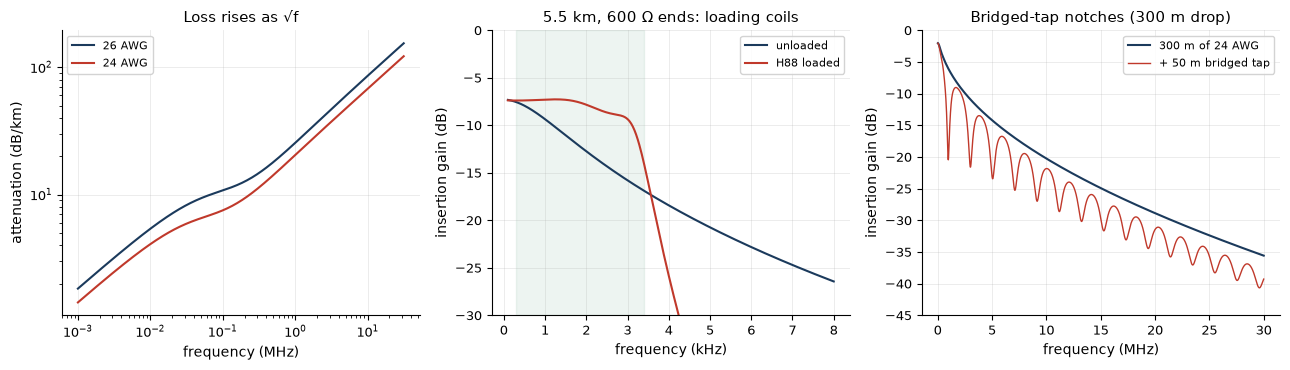

,
"R, L, C per km at 1 MHz","627 Ω, 0.57 mH, 49 nF"
|Z0| at 1 MHz,109 Ω
attenuation at 1 MHz,25.4 dB/km
insertion loss of 3 km at 1 MHz,76.2 dB
phase velocity / c,0.63
loop delay,16.0 µs
"first bridged-tap notch, quarter wave c·0.63/(4l)",0.94 MHz


In [3]:
def loop_demo(length_km=3.0, awg=26, tap_m=50.0):
    f = np.logspace(3, 8, 400)
    f, ax = lk.fig((13, 3.8), 1, 3), None
    fig, ax = f
    fr = np.logspace(3, 7.5, 400)
    for g, col in [(26, lk.NAVY), (24, lk.RED)]:
        ax[0].loglog(fr / 1e6, wl.attenuation_db_per_km(fr, g), color=col, label=f"{g} AWG")
    ax[0].set_xlabel("frequency (MHz)"); ax[0].set_ylabel("attenuation (dB/km)"); ax[0].legend(fontsize=8); ax[0].set_title("Loss rises as √f")
    fv = np.linspace(100, 8000, 400)
    L_tot = 18000 * 0.3048; d = 6000 * 0.3048
    coil = wl.series_abcd(8.0 + 1j * 2 * np.pi * fv * 88e-3)
    secs = [wl.line_abcd(fv, d / 2, 26)]
    for _ in range(2):
        secs += [coil, wl.line_abcd(fv, d, 26)]
    secs += [coil, wl.line_abcd(fv, L_tot - d / 2 - 2 * d, 26)]
    ax[1].plot(fv / 1e3, lk.db(np.abs(wl.insertion_gain(wl.line_abcd(fv, L_tot, 26), 600, 600)) ** 2), color=lk.NAVY, label="unloaded")
    ax[1].plot(fv / 1e3, lk.db(np.abs(wl.insertion_gain(wl.cascade(*secs), 600, 600)) ** 2), color=lk.RED, label="H88 loaded")
    ax[1].axvspan(0.3, 3.4, color=lk.GREEN, alpha=0.08); ax[1].set_ylim(-30, 0); ax[1].legend(fontsize=8)
    ax[1].set_xlabel("frequency (kHz)"); ax[1].set_ylabel("insertion gain (dB)"); ax[1].set_title("5.5 km, 600 Ω ends: loading coils")
    fb = np.linspace(20e3, 30e6, 2000)
    L = length_km * 1e3
    base = wl.line_abcd(fb, 300, 24)                          # a short VDSL2 drop, as in Chapter 24's figure
    tapped = wl.cascade(wl.line_abcd(fb, 200, 24), wl.bridged_tap_abcd(fb, tap_m, 24), wl.line_abcd(fb, 100, 24))
    ax[2].plot(fb / 1e6, lk.db(np.abs(wl.insertion_gain(base)) ** 2), color=lk.NAVY, label="300 m of 24 AWG")
    ax[2].plot(fb / 1e6, lk.db(np.abs(wl.insertion_gain(tapped)) ** 2), color=lk.RED, lw=1, label=f"+ {tap_m:g} m bridged tap")
    ax[2].set_ylim(-45, 0); ax[2].set_xlabel("frequency (MHz)"); ax[2].set_ylabel("insertion gain (dB)"); ax[2].legend(fontsize=8)
    ax[2].set_title("Bridged-tap notches (300 m drop)")
    lk.show(fig)
    f1 = np.array([1e6])
    R, Lh, G, Cc = wl.rlgc_twisted_pair(f1, awg)
    gam, Z0 = wl.propagation(f1, awg)
    v = 2 * np.pi * 1e6 / gam.imag[0]
    _, Z0t = wl.propagation(np.array([1e6]), awg)
    lk.table([["R, L, C per km at 1 MHz", f"{R[0] * 1e3:.0f} Ω, {Lh[0] * 1e6:.2f} mH, {Cc[0] * 1e12:.0f} nF"],
              ["|Z0| at 1 MHz", f"{abs(Z0[0]):.0f} Ω"], ["attenuation at 1 MHz", f"{wl.attenuation_db_per_km(f1, awg)[0]:.1f} dB/km"],
              [f"insertion loss of {length_km:g} km at 1 MHz", f"{-lk.db(np.abs(wl.loop_gain(f1, L, awg)) ** 2)[0]:.1f} dB"],
              ["phase velocity / c", f"{v / wl.C:.2f}"], ["loop delay", f"{L / v * 1e6:.1f} µs"],
              ["first bridged-tap notch, quarter wave c·0.63/(4l)", f"{v / (4 * tap_m) / 1e6:.2f} MHz"]], ["", ""])

lk.interact(loop_demo, length_km=lk.slider(3.0, 0.2, 6.0, 0.1, "loop length (km)"), awg=lk.choice([26, 24], 26, "gauge (AWG)"),
            tap_m=lk.slider(50, 5, 300, 5, "bridged tap length (m)"))

**What you should see.** The table reproduces the chapter: about 25 dB/km at 1 MHz for 26 AWG, about 76 dB for 3 km, $|Z_0|$
near 108 Ω, a velocity of about $0.63c$ and a loop delay of 16 µs. Loading coils flatten the voice band but cut off above 4 kHz,
which is why a loaded loop cannot carry DSL until the coils are removed. A bridged tap adds periodic notches whose first
null is where the tap is a quarter wavelength long.

### Try it yourself 1.1
Using the model, what is the attenuation (dB/km) of 24 AWG cable at 1 MHz?

In [5]:
answer_1_1 = None
lk.check("1.1 24 AWG attenuation at 1 MHz (dB/km)", answer_1_1, float(wl.attenuation_db_per_km(np.array([1e6]), 24)[0]), atol=0.3)

[TODO] 1.1 24 AWG attenuation at 1 MHz (dB/km): not attempted yet: replace the None with your answer

## 2. DSL: bit loading and rate versus reach

DMT loads each 4.3125 kHz tone with $b = \lfloor\log_2(1 + \mathrm{SNR}/\Gamma)\rfloor$ bits, capped at 15, and sends 4000 DMT
symbols per second. Chapter 24's worked example: ADSL2+ on 2 km of 26 AWG, transmit PSD −40 dBm/Hz, background −140 dBm/Hz, FEXT
from 10 other ADSL2+ lines, $\Gamma = 12$ dB: about 4470 bits per symbol, 17.9 Mb/s; about 8 Mb/s at 3 km and 3.6 Mb/s at 4 km.

### Interactive: loop length and noise

[info] Interactive panel, shown here at its default settings: run the notebook in Jupyter to move the controls.

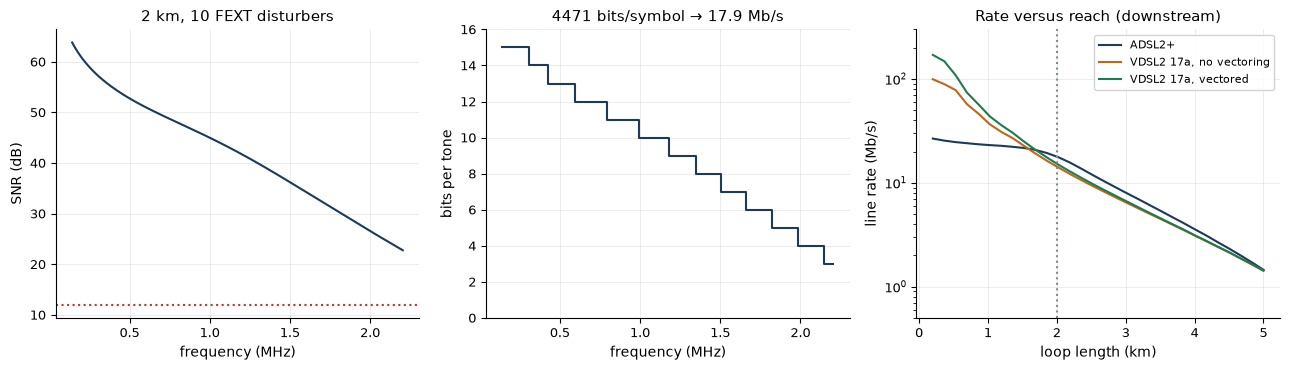

frequency (MHz),loop loss (dB),SNR (dB),bits
0.20,25,61,15
0.50,36,53,13
1.00,51,45,10
1.50,63,36,8


In [7]:
def dsl_demo(L_km=2.0, n_fext=10, noise=-140.0, gap=12.0):
    r, f, b, snr = adsl_rate(L_km * 1e3, n_fext, noise=noise, gap=gap, return_all=True)
    fig, ax = lk.fig((13, 3.8), 1, 3)
    ax[0].plot(f / 1e6, snr, color=lk.NAVY); ax[0].axhline(gap, color=lk.RED, ls=":")
    ax[0].set_xlabel("frequency (MHz)"); ax[0].set_ylabel("SNR (dB)"); ax[0].set_title(f"{L_km:g} km, {n_fext} FEXT disturbers")
    ax[1].step(f / 1e6, b, where="mid", color=lk.NAVY); ax[1].set_ylim(0, 16)
    ax[1].set_xlabel("frequency (MHz)"); ax[1].set_ylabel("bits per tone"); ax[1].set_title(f"{int(b.sum())} bits/symbol → {r / 1e6:.1f} Mb/s")
    Ls = np.linspace(200, 5000, 30)
    ax[2].semilogy(Ls / 1e3, [adsl_rate(x, n_fext, noise=noise, gap=gap) / 1e6 for x in Ls], color=lk.NAVY, label="ADSL2+")
    ax[2].semilogy(Ls / 1e3, [vdsl_rate(x) / 1e6 for x in Ls], color=lk.ORANGE, label="VDSL2 17a, no vectoring")
    ax[2].semilogy(Ls / 1e3, [vdsl_rate(x, cancel_db=25.0) / 1e6 for x in Ls], color=lk.GREEN, label="VDSL2 17a, vectored")
    ax[2].axvline(L_km, color=lk.GRAY, ls=":"); ax[2].set_ylim(0.5, 300); ax[2].legend(fontsize=8)
    ax[2].set_xlabel("loop length (km)"); ax[2].set_ylabel("line rate (Mb/s)"); ax[2].set_title("Rate versus reach (downstream)")
    lk.show(fig)
    rows = []
    for ft in (0.2e6, 0.5e6, 1.0e6, 1.5e6):
        k = np.argmin(abs(f - ft))
        rows.append([f"{f[k] / 1e6:.2f}", -lk.db(np.abs(wl.loop_gain(f[k:k + 1], L_km * 1e3, 26)) ** 2)[0], snr[k], int(b[k])])
    lk.table(rows, ["frequency (MHz)", "loop loss (dB)", "SNR (dB)", "bits"], fmt=".0f", title="Compare with Chapter 24's 2 km table")

lk.interact(dsl_demo, L_km=lk.slider(2.0, 0.3, 5.5, 0.1, "loop length (km)"), n_fext=lk.islider(10, 0, 49, 1, "FEXT disturbers"),
            noise=lk.slider(-140, -150, -110, 1, "background noise (dBm/Hz)"), gap=lk.slider(12, 6, 18, 0.5, "SNR gap Γ (dB)"))

**What you should see.** At 2 km: losses of about 25, 36, 51 and 63 dB at 0.2, 0.5, 1.0 and 1.5 MHz, SNRs of about 61, 53, 45 and
36 dB, and 15, 13, 10 and 8 bits, exactly the chapter's table; the line rate is about 17.9 Mb/s. Rate falls steeply with reach.
VDSL2's 17 MHz band only helps on short loops, and there FEXT is the limit, which vectoring removes.

### Try it yourself 2.1
What ADSL2+ rate (Mb/s) does the model give on 3 km with the default noise?

In [9]:
answer_2_1 = None
lk.check("2.1 ADSL2+ rate at 3 km (Mb/s)", answer_2_1, adsl_rate(3000) / 1e6, atol=0.2)

[TODO] 2.1 ADSL2+ rate at 3 km (Mb/s): not attempted yet: replace the None with your answer

## 3. Crosstalk and vectoring

On one tone, a binder of $K$ lines is a $K \times K$ MIMO channel $\mathbf H$: the diagonal is each line's own loop, the off-diagonal
entries are FEXT couplings, tens of dB weaker but adding up. Because all the downstream transmitters sit in one DSLAM, the DSLAM can
**precode** (G.993.5 vectoring): send $\mathbf x = \mathbf P\mathbf s$ with $\mathbf P = \mathbf H^{-1}\mathrm{diag}(\mathbf H)$, so each
receiver sees only its own loop. Because $\mathbf H$ is strongly diagonally dominant, $\mathbf P \approx \mathbf I$ and the power penalty
is tiny. A line *outside* the vectored group (alien crosstalk) cannot be cancelled. Below: $K$ lines of the same length with random
FEXT phases and 1%-worst-case magnitudes, VDSL2 17a downstream tones.

### Interactive: binder size and alien crosstalk

[info] Interactive panel, shown here at its default settings: run the notebook in Jupyter to move the controls.

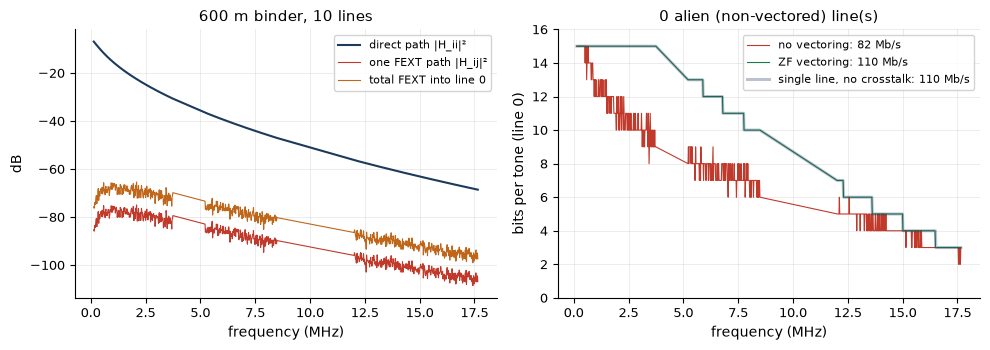

,
"mean rate, no vectoring",82.4 Mb/s
"mean rate, ZF vectoring",109.9 Mb/s
single-line bound,109.9 Mb/s
worst precoder power penalty,0.02 dB


In [11]:
def vector_demo(L_m=600.0, K=10, alien=0, decim=4):
    r = np.random.default_rng(4)
    f = np.arange(1, 4096, decim) * 4312.5
    m = np.zeros_like(f, bool)
    for lo, hi in VDSL_DS:
        m |= (f >= lo) & (f < hi)
    f = f[m]
    h = wl.loop_gain(f, L_m, 26)
    Ktot = K + alien
    # per-pair FEXT power so that K-1 disturbers sum to the (K-1)-disturber model
    pf = wl.fext_coupling(f, L_m, h, max(Ktot - 1, 1)) / max(Ktot - 1, 1)
    H = (np.sqrt(pf)[:, None, None] * (r.standard_normal((len(f), Ktot, Ktot)) + 1j * r.standard_normal((len(f), Ktot, Ktot))) / np.sqrt(2))
    idx = np.arange(Ktot)
    H[:, idx, idx] = h[:, None]
    psd = -40.0 - 10.0                                       # -50 dBm/Hz per line
    P = lk.undb(psd); N = lk.undb(NOISE)
    Hv = H[:, :K, :K]
    # no vectoring: all crosstalk is noise
    sig = P * np.abs(h[:, None]) ** 2 * np.ones((1, K))
    xt = P * (np.sum(np.abs(H[:, :K, :]) ** 2, axis=2) - np.abs(h[:, None]) ** 2)
    snr_nv = sig / (xt + N)
    # ZF precoding inside the vectored group; alien lines still leak in
    Pz = np.linalg.inv(Hv) @ (np.eye(K)[None] * h[:, None, None])
    scale = np.max(np.sum(np.abs(Pz) ** 2, axis=2), axis=1)            # keep every line within its PSD
    xt_alien = P * np.sum(np.abs(H[:, :K, K:]) ** 2, axis=2)
    snr_v = (sig / scale[:, None]) / (xt_alien + N)
    bits = lambda s: np.clip(np.floor(np.log2(1 + s / lk.undb(GAP))), 0, 15)
    rate = lambda s: bits(s).sum(axis=0) * 4000 * decim / 1e6
    r_nv, r_v = rate(snr_nv), rate(snr_v)
    r_single = rate(sig / N)
    fig, ax = lk.fig("row2", 1, 2)
    ax[0].plot(f / 1e6, lk.db(np.abs(h) ** 2), color=lk.NAVY, label="direct path |H_ii|²")
    ax[0].plot(f / 1e6, lk.db(np.mean(np.abs(H[:, 0, 1:]) ** 2, axis=1)), color=lk.RED, lw=0.8, label="one FEXT path |H_ij|²")
    ax[0].plot(f / 1e6, lk.db(xt[:, 0] / P), color=lk.ORANGE, lw=0.8, label="total FEXT into line 0")
    ax[0].set_xlabel("frequency (MHz)"); ax[0].set_ylabel("dB"); ax[0].legend(fontsize=8); ax[0].set_title(f"{L_m:g} m binder, {Ktot} lines")
    ax[1].plot(f / 1e6, bits(snr_nv[:, 0]), color=lk.RED, lw=0.8, label=f"no vectoring: {r_nv.mean():.0f} Mb/s")
    ax[1].plot(f / 1e6, bits(snr_v[:, 0]), color=lk.GREEN, lw=0.8, label=f"ZF vectoring: {r_v.mean():.0f} Mb/s")
    ax[1].plot(f / 1e6, bits(sig[:, 0] / N), color=lk.NAVY, lw=2.2, alpha=0.3, label=f"single line, no crosstalk: {r_single.mean():.0f} Mb/s")
    ax[1].set_xlabel("frequency (MHz)"); ax[1].set_ylabel("bits per tone (line 0)"); ax[1].set_ylim(0, 16); ax[1].legend(fontsize=8)
    ax[1].set_title(f"{alien} alien (non-vectored) line(s)")
    lk.show(fig)
    lk.table([["mean rate, no vectoring", f"{r_nv.mean():.1f} Mb/s"], ["mean rate, ZF vectoring", f"{r_v.mean():.1f} Mb/s"],
              ["single-line bound", f"{r_single.mean():.1f} Mb/s"], ["worst precoder power penalty", f"{lk.db(scale.max()):.2f} dB"]], ["", ""])

lk.interact(vector_demo, L_m=lk.slider(600, 100, 1500, 50, "loop length (m)"), K=lk.islider(10, 2, 24, 1, "vectored lines"),
            alien=lk.islider(0, 0, 4, 1, "alien lines"), decim=lk.choice([1, 2, 4, 8], 4, "tone decimation (speed)"))

**What you should see.** FEXT, summed over the binder, sits a few tens of dB below the direct path and rises with frequency, so it
caps the SNR on the high tones. Zero-forcing precoding restores the single-line loading almost exactly with a power penalty of a
small fraction of a dB, the same picture as Chapter 24's model, which gives about 69 Mb/s without and 91 Mb/s with vectoring on 600 m
(slightly different numbers here: a different PSD and random couplings). Add one alien line and much of the vectoring gain disappears:
the reason operators fought over exclusive access to street cabinets.

## 4. Fibre: loss, dispersion, IM/DD versus coherent

Silica loses about 0.2 dB/km at 1550 nm (Rayleigh scattering $\propto \lambda^{-4}$ below, infrared absorption above). Standard
G.652 fibre has a dispersion of about 17 ps/(nm·km) there: different wavelengths travel at different speeds. Chapter 24's worked
example: 80 km accumulates 1360 ps/nm; a 32 GBd signal is 0.256 nm wide, so pulses spread by about 350 ps, about 11 symbols.
**Direct detection** sees only power, so the two sidebands of an intensity-modulated signal, rotated in opposite directions by
dispersion, cancel at $f_k = \sqrt{(2k+1)c/(2DL\lambda^2)}$. A **coherent** receiver measures the field and undoes dispersion with
an all-pass filter.

### Interactive: fibre length and baud rate

[info] Interactive panel, shown here at its default settings: run the notebook in Jupyter to move the controls.

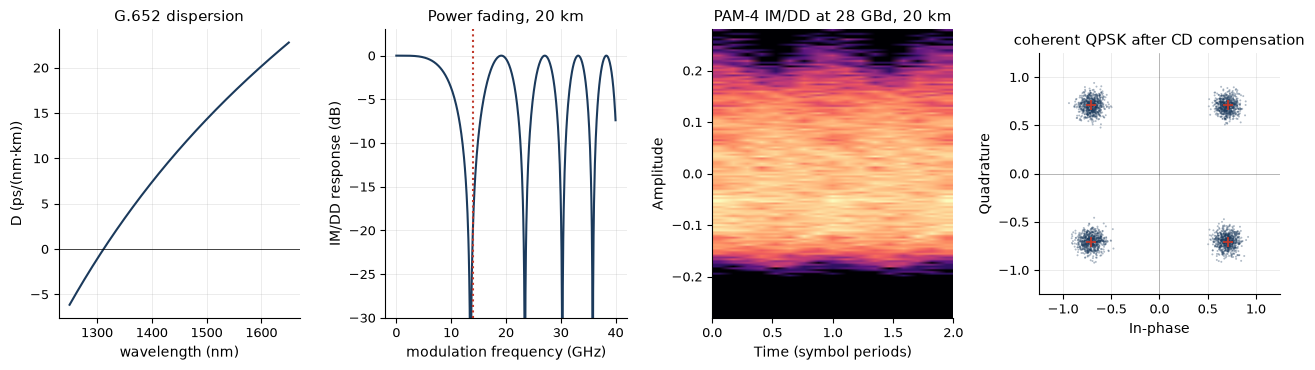

,
accumulated dispersion DL,340 ps/nm
signal width λ²R_s/c,0.224 nm
pulse spread DLΔλ,76 ps = 2.1 symbols
first IM/DD null,13.5 GHz
Nyquist frequency of the signal,14 GHz


In [13]:
def fibre_demo(L_km=20.0, baud_g=28.0):
    r = np.random.default_rng(1)
    sps, nsym = 8, 3000
    fs = baud_g * 1e9 * sps
    taps = cl.rrc_taps(0.3, sps, span=16)
    lev = r.integers(0, 4, nsym)
    pam = cl.shape((lev / 3.0) * 0.8 + 0.1, taps, sps).real                   # intensity levels between 0.1 and 0.9
    field = np.sqrt(np.maximum(pam, 1e-4))                                    # chirp-free modulator: field = sqrt(power)
    det = np.abs(wl.apply_cd(field, fs, L_km * 1e3)) ** 2                      # photodiode
    det = det - det.mean() + 0.01 * r.standard_normal(len(det))              # AC-coupled receiver plus a little noise
    qp = cl.get_constellation("qpsk").modulate(r.integers(0, 2, 2 * nsym))
    coh = cl.shape(qp, taps, sps)
    rxc = wl.apply_cd(coh, fs, L_km * 1e3)
    rxc = rxc + np.sqrt(lk.undb(-20) * np.mean(np.abs(rxc) ** 2) * sps / 2) * (r.standard_normal(len(rxc)) + 1j * r.standard_normal(len(rxc)))
    eq = wl.cd_compensate(rxc, fs, L_km * 1e3)
    mf = lambda x: np.convolve(x, taps, "same")
    fig, ax = lk.fig((13, 3.8), 1, 4)
    lam = np.linspace(1250, 1650, 300)
    ax[0].plot(lam, wl.dispersion_ps_nm_km(lam), color=lk.NAVY); ax[0].axhline(0, color="k", lw=0.5)
    ax[0].set_xlabel("wavelength (nm)"); ax[0].set_ylabel("D (ps/(nm·km))"); ax[0].set_title("G.652 dispersion")
    fr = np.linspace(0.01, 40, 500) * 1e9
    ax[1].plot(fr / 1e9, lk.db(np.abs(wl.imdd_cd_response(fr, L_km * 1e3)) ** 2 + 1e-6), color=lk.NAVY)
    ax[1].axvline(baud_g / 2, color=lk.RED, ls=":"); ax[1].set_ylim(-30, 3)
    ax[1].set_xlabel("modulation frequency (GHz)"); ax[1].set_ylabel("IM/DD response (dB)"); ax[1].set_title(f"Power fading, {L_km:g} km")
    lk.eye_density(ax[2], det[400 * sps:], sps, 2, offset=sps // 2, upsample=1)
    ax[2].set_title(f"PAM-4 IM/DD at {baud_g:g} GBd, {L_km:g} km")
    y = mf(eq)[16 * sps::sps][100:-100]
    lk.constellation(ax[3], y / np.sqrt(np.mean(np.abs(y) ** 2)), cl.get_constellation("qpsk").points, "coherent QPSK after CD compensation", s=2)
    lk.show(fig)
    D, lam0 = 17e-6, 1550e-9
    f1 = np.sqrt(wl.C / (2 * D * L_km * 1e3 * lam0 ** 2))
    dl = lam0 ** 2 * baud_g * 1e9 / wl.C
    lk.table([["accumulated dispersion DL", f"{17 * L_km:.0f} ps/nm"], ["signal width λ²R_s/c", f"{dl * 1e9:.3f} nm"],
              ["pulse spread DLΔλ", f"{17 * L_km * dl * 1e9:.0f} ps = {17 * L_km * dl * 1e9 * baud_g / 1e3:.1f} symbols"],
              ["first IM/DD null", f"{f1 / 1e9:.1f} GHz"], ["Nyquist frequency of the signal", f"{baud_g / 2:g} GHz"]], ["", ""])

lk.interact(fibre_demo, L_km=lk.slider(20, 0, 100, 1, "fibre length (km)"), baud_g=lk.choice([10.0, 28.0, 32.0, 56.0], 28.0, "symbol rate (GBd)"))

**What you should see.** At 28 GBd and 20 km the first IM/DD null (13.5 GHz) has moved inside the signal band, below the 14 GHz
Nyquist frequency, and the PAM-4 eye is closed (at 10 km the null is at 19 GHz and the eye is still open); the coherent QPSK
constellation after CD compensation, with 20 dB SNR, is equally clean at any length. Set 32 GBd and 80 km: the table gives
1360 ps/nm, 0.256 nm and about 350 ps (11 symbols) of spread, as in the chapter, and the first null at 6.8 GHz is the reason 10 Gb/s
IM/DD reaches about 80 km while 50–100 GBd IM/DD links stay within a few kilometres or move to the O band.

### Try it yourself 4.1
How many ps/nm does a 6000 km transpacific link of 17 ps/(nm·km) fibre accumulate?

In [15]:
answer_4_1 = None
lk.check("4.1 accumulated dispersion over 6000 km (ps/nm)", answer_4_1, 17 * 6000, atol=1)

[TODO] 4.1 accumulated dispersion over 6000 km (ps/nm): not attempted yet: replace the None with your answer

## 5. The coherent receiver DSP chain

A dual-polarisation coherent receiver mixes the signal with a local-oscillator laser and samples four ADC streams. Its DSP undoes,
in order: **chromatic dispersion** (a fixed all-pass filter), **polarisation rotation and PMD** (a 2 × 2 butterfly of FIR filters
adapted blindly by the constant-modulus algorithm, CMA), the **frequency offset** between the lasers (the peak of the fourth-power
spectrum for QPSK) and **laser phase noise** (Viterbi–Viterbi fourth-power phase estimation over a sliding block). This is Chapter 24's
Figure 24-*coherent-dsp*, 32 GBd DP-QPSK over 80 km.

### Interactive: impairments

[info] Interactive panel, shown here at its default settings: run the notebook in Jupyter to move the controls.

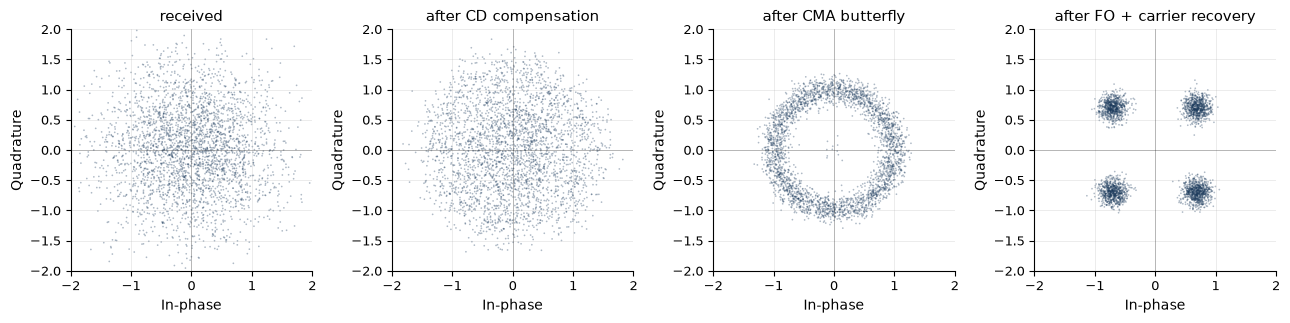

,
frequency offset estimate,150.4 MHz (true 150)
EVM after recovery (decision-directed),-15.7 dB
CD filter length needed ≈ DLΔλ·R_s,11 symbols


In [17]:
def coherent_demo(L_km=80.0, linewidth_khz=200.0, fo_mhz=150.0, snr_db=16.0, theta=0.6):
    r = np.random.default_rng(7)
    rs, sps = 32e9, 2
    fs = rs * sps; nsym = 8000
    qpsk = (np.array([1, -1])[r.integers(0, 2, (2, nsym))] + 1j * np.array([1, -1])[r.integers(0, 2, (2, nsym))]) / np.sqrt(2)
    taps = cl.rrc_taps(0.1, sps, span=32)
    tx = np.array([cl.shape(qpsk[p], taps, sps) for p in range(2)])
    tx /= np.sqrt(np.mean(np.abs(tx) ** 2, axis=1, keepdims=True))
    U = np.array([[np.cos(theta), -np.sin(theta) * np.exp(-1.1j)], [np.sin(theta) * np.exp(1.1j), np.cos(theta)]])
    f = np.fft.fftfreq(tx.shape[1], 1 / fs)
    Xf = np.fft.fft(tx, axis=1); Xf[0] *= np.exp(-1j * np.pi * f * 8e-12); Xf[1] *= np.exp(1j * np.pi * f * 8e-12)   # 8 ps DGD
    rx = U @ np.fft.ifft(Xf, axis=1)
    rx = np.array([wl.apply_cd(rx[p], fs, L_km * 1e3) for p in range(2)])
    n = rx.shape[1]
    phase = np.cumsum(r.normal(0, np.sqrt(2 * np.pi * linewidth_khz * 1e3 / fs), n)) + 2 * np.pi * fo_mhz * 1e6 * np.arange(n) / fs
    rx = rx * np.exp(1j * phase)
    rx = rx + np.sqrt(np.mean(np.abs(rx) ** 2) / lk.undb(snr_db) / 2 * sps) * (r.normal(size=rx.shape) + 1j * r.normal(size=rx.shape))
    mf = np.array([np.convolve(rx[p], taps, mode="same") for p in range(2)])
    cdc = np.array([wl.cd_compensate(mf[p], fs, L_km * 1e3) for p in range(2)])
    nrm = lambda z: z / np.sqrt(np.mean(np.abs(z) ** 2))
    zx, zy, W = wl.cma_butterfly(nrm(cdc[0]), nrm(cdc[1]), ntaps=15, mu=2e-3, sps=2)
    fo = wl.fourth_power_fo(zx[3000:], rs)
    zc = zx[3000:] * np.exp(-1j * 2 * np.pi * fo * np.arange(len(zx) - 3000) / rs)
    z3, ph = wl.vv_carrier_recovery(zc, block=40)
    stages = [mf[0, ::sps][200:-200], cdc[0, ::sps][200:-200], zx[3000:], z3[50:-50]]
    fig, ax = lk.fig((13, 3.4), 1, 4)
    for a, z, t in zip(ax, stages, ["received", "after CD compensation", "after CMA butterfly", "after FO + carrier recovery"]):
        z = nrm(z[-3000:])
        lk.constellation(a, z, None, t, lim=2, s=1.5)
    lk.show(fig)
    ref = (np.sign(z3.real) + 1j * np.sign(z3.imag)) / np.sqrt(2)
    zz = nrm(z3[100:-100]); rr = ref[100:-100]
    evm = lk.db(np.mean(np.abs(zz - rr) ** 2))
    lk.table([["frequency offset estimate", f"{fo / 1e6:.1f} MHz (true {fo_mhz:g})"], ["EVM after recovery (decision-directed)", f"{evm:.1f} dB"],
              ["CD filter length needed ≈ DLΔλ·R_s", f"{17 * L_km * (1550e-9) ** 2 * rs / wl.C * 1e9 * rs * 1e-12:.0f} symbols"]], ["", ""])

lk.interact(coherent_demo, L_km=lk.slider(80, 0, 2000, 10, "fibre length (km)"), linewidth_khz=lk.slider(200, 10, 2000, 10, "combined laser linewidth (kHz)"),
            fo_mhz=lk.slider(150, -1000, 1000, 10, "frequency offset (MHz)"), snr_db=lk.slider(16, 6, 30, 1, "SNR (dB)"),
            theta=lk.slider(0.6, 0, 1.57, 0.05, "polarisation rotation (rad)"))

**What you should see.** The received constellation is a featureless cloud (dispersion smears each symbol over about 11 neighbours);
CD compensation turns it into a ring (the two polarisations are still mixed and the phase is spinning); the CMA butterfly separates
the polarisations and restores constant modulus; frequency and phase recovery give four clean QPSK clusters. (Viterbi–Viterbi has a
four-fold phase ambiguity; real systems resolve it with pilots or differential coding.) Raise the linewidth to 2 MHz: the phase
tracker's 40-symbol block averages too much and the clusters smear.

## 6. Optical budgets: OSNR, nonlinearity, PON

After $N$ amplified spans of loss $L_s$ and amplifier noise figure NF, the optical SNR in 0.1 nm is
$\mathrm{OSNR} = P_{ch} - L_s - \mathrm{NF} - 10\log_{10}N + 58$ dB. Raising the launch power raises OSNR, but the Kerr nonlinearity
adds interference that grows as $P^3$ (the GN model), so there is an optimum, about 1 dBm per channel for a full C band. Chapter 24's
worked example: 13 spans of 17.6 dB, NF 5 dB, 1 dBm: OSNR 25.3 dB; in 64 GHz the SNR is 18.2 dB, about 16.4 dB with nonlinearity, against
14.7 dB needed by DP-16QAM with a soft-decision FEC and 2 dB implementation penalty.

### Interactive: link plan

[info] Interactive panel, shown here at its default settings: run the notebook in Jupyter to move the controls.

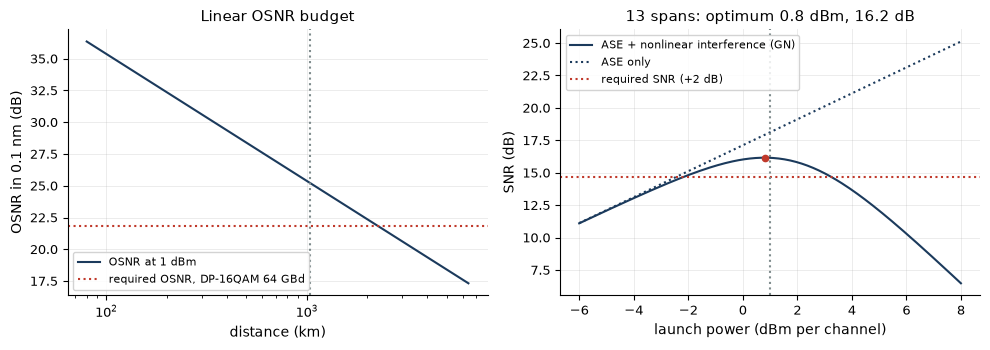

"1040 km, DP-16QAM 64 GBd",
OSNR in 0.1 nm,25.2 dB
ASE-limited SNR in 64 GHz,18.1 dB
SNR with nonlinearity (GN model) at this power,16.2 dB
"required SNR, pre-FEC BER 2e-2, + 2 dB",14.7 dB
margin,1.4 dB


GPON downstream budget (Chapter 24),dB / dBm
"fibre, 20 km × 0.30 dB/km (1490 nm)",6.0
1:32 splitter incl. excess loss,17.0
4 connectors × 0.3 dB,1.2
10 splices × 0.1 dB,1.0
total loss (class B+ allows 28 dB),25.2
received power at +1.5 dBm launch,-23.7
margin over −27 dBm sensitivity,3.3


In [19]:
def req_snr_db(M, ber=2e-2):
    return brentq(lambda s: cl.ber_mqam_gray(s, M) - ber, -5, 40)

def budget_demo(n_spans=13, span_db=17.6, nf_db=5.0, p_dbm=1.0, fmt="DP-16QAM 64 GBd"):
    M, rs = {"DP-QPSK 32 GBd": (4, 32e9), "DP-16QAM 64 GBd": (16, 64e9), "DP-64QAM 64 GBd": (64, 64e9)}[fmt]
    osnr = wl.osnr_db(p_dbm, span_db, nf_db, n_spans)
    snr_ase = osnr - lk.db(rs / 12.5e9)
    eta = wl.gn_eta(rs=rs)
    Pd = np.linspace(-6, 8, 200); Pw = 1e-3 * lk.undb(Pd)
    snr_gn = lk.db(wl.gn_snr(Pw, n_spans, span_db, nf_db, rs=rs, eta=eta))
    snr_here = float(lk.db(wl.gn_snr(1e-3 * lk.undb(p_dbm), n_spans, span_db, nf_db, rs=rs, eta=eta)))
    need = req_snr_db(M) + 2.0
    fig, ax = lk.fig("row2", 1, 2)
    Ns = np.arange(1, 81)
    ax[0].plot(Ns * 80, wl.osnr_db(p_dbm, span_db, nf_db, Ns), color=lk.NAVY, label=f"OSNR at {p_dbm:g} dBm")
    ax[0].axhline(need + lk.db(rs / 12.5e9), color=lk.RED, ls=":", label=f"required OSNR, {fmt}")
    ax[0].axvline(n_spans * 80, color=lk.GRAY, ls=":"); ax[0].set_xscale("log")
    ax[0].set_xlabel("distance (km)"); ax[0].set_ylabel("OSNR in 0.1 nm (dB)"); ax[0].legend(fontsize=8); ax[0].set_title("Linear OSNR budget")
    ax[1].plot(Pd, snr_gn, color=lk.NAVY, label="ASE + nonlinear interference (GN)")
    ax[1].plot(Pd, lk.db(wl.gn_snr(Pw, n_spans, span_db, nf_db, rs=rs, eta=0.0)), ":", color=lk.NAVY, label="ASE only")
    ax[1].axhline(need, color=lk.RED, ls=":", label="required SNR (+2 dB)"); ax[1].axvline(p_dbm, color=lk.GRAY, ls=":")
    k = np.argmax(snr_gn); ax[1].plot(Pd[k], snr_gn[k], "o", color=lk.RED)
    ax[1].set_xlabel("launch power (dBm per channel)"); ax[1].set_ylabel("SNR (dB)"); ax[1].legend(fontsize=8)
    ax[1].set_title(f"{n_spans} spans: optimum {Pd[k]:.1f} dBm, {snr_gn[k]:.1f} dB")
    lk.show(fig)
    lk.table([["OSNR in 0.1 nm", f"{osnr:.1f} dB"], [f"ASE-limited SNR in {rs / 1e9:g} GHz", f"{snr_ase:.1f} dB"],
              ["SNR with nonlinearity (GN model) at this power", f"{snr_here:.1f} dB"], ["required SNR, pre-FEC BER 2e-2, + 2 dB", f"{need:.1f} dB"],
              ["margin", f"{snr_here - need:.1f} dB"]], [f"{n_spans * 80} km, {fmt}", ""])

lk.interact(budget_demo, n_spans=lk.islider(13, 1, 80, 1, "spans of 80 km"), span_db=lk.slider(17.6, 10, 25, 0.1, "span loss (dB)"),
            nf_db=lk.slider(5, 3, 8, 0.5, "amplifier NF (dB)"), p_dbm=lk.slider(1, -6, 8, 0.5, "launch power (dBm/ch)"),
            fmt=lk.choice(["DP-QPSK 32 GBd", "DP-16QAM 64 GBd", "DP-64QAM 64 GBd"], "DP-16QAM 64 GBd", "format"))

gpon = [["fibre, 20 km × 0.30 dB/km (1490 nm)", 6.0], ["1:32 splitter incl. excess loss", 17.0], ["4 connectors × 0.3 dB", 1.2], ["10 splices × 0.1 dB", 1.0]]
tot = sum(x[1] for x in gpon)
lk.table(gpon + [["total loss (class B+ allows 28 dB)", tot], ["received power at +1.5 dBm launch", 1.5 - tot], ["margin over −27 dBm sensitivity", 1.5 - tot + 27]],
         ["GPON downstream budget (Chapter 24)", "dB / dBm"], fmt=".1f")

**What you should see.** The defaults reproduce the chapter: OSNR 25.2 dB (the chapter's rounded constant 58 gives 25.3), an
ASE-limited SNR of 18.1 dB, an optimum launch power near 1 dBm, an SNR of about 16.2 dB with nonlinearity and a margin of about
1.5 dB, "under 2 dB" as the chapter says, for 400G DP-16QAM over 1040 km. Switch to DP-QPSK at 32 GBd: the margin grows past 10 dB and
the reach to thousands of kilometres. Raise the launch power beyond the optimum and the SNR *falls*: the nonlinear Shannon limit. The GPON
table reproduces the chapter's budget: 25.2 dB of loss, −23.7 dBm received, 3.3 dB of margin; the splitter, not the fibre, dominates.

### Try it yourself 6.1
By the OSNR formula, how much does the OSNR change when the number of spans doubles?

In [21]:
answer_6_1 = None
lk.check("6.1 OSNR change for twice the spans (dB)", answer_6_1, -10 * np.log10(2), atol=0.05)

[TODO] 6.1 OSNR change for twice the spans (dB): not attempted yet: replace the None with your answer

## Key takeaways
* Twisted-pair loss grows as √f (skin effect); loading coils and bridged taps shape the response; Z0 ≈ 100 Ω at DSL frequencies.
* DMT loads every tone to its SNR: rate falls steeply with reach, and FEXT, not noise, limits short loops.
* Vectoring is MIMO precoding in the DSLAM: it removes FEXT inside the group, not alien crosstalk.
* Dispersion destroys high-baud IM/DD after a few km (power fading); coherent receivers undo it with an all-pass filter.
* The coherent DSP chain: CD compensation → CMA butterfly → frequency offset → carrier phase.
* Amplified links have an optimum launch power set by ASE versus Kerr nonlinearity; PON budgets are dominated by the splitter.

## Going further (hardware: USRP B200 / GNU Radio)
* The B200 is a radio, but a twisted pair can be its channel: transmit the OFDM link of `gnuradio/gr04_ofdm_link.py` at a low
  frequency through a long pair (via a balun and an attenuator) and measure the channel estimate's slope against Section 1.
* Capture a DOCSIS or DVB-C downstream with the B200 from a cable outlet (through a splitter and attenuator) and identify its QAM channels.

## Exercises
1. **(Warm-up)** Derive $\alpha \approx R/(2Z_0)$ from $\gamma = \sqrt{(R+j\omega L)(G+j\omega C)}$ for $\omega L \gg R$, $G \approx 0$.
2. **(Core)** Replace ZF vectoring with a diagonalising precoder computed from a noisy estimate of H and plot the rate against the estimation SNR.
3. **(Core)** Add 1 ps of DGD per √(100 km) to Section 5 and find the CMA tap count needed at 2000 km.
4. **(Stretch)** Implement digital back-propagation (split-step with negative γ) for a single channel and measure the SNR gain at high launch power.

In [23]:
lk.summary()

[good] Lab 30 finished in 2.6 s. Self-checks: 0 passed, 0 failed, 4 still to do.